### Importing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import plotly.graph_objs as go

from keras.models import Sequential
from keras.layers import LSTM, Dense, Input, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from plotly.subplots import make_subplots
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Loading Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Case studies/4. Airline Passenger Forecasting/International Airline Passengers.csv'

df = pd.read_csv(file_path)
print(df.head())

     Month  No_passengers_thousands
0  1949-01                      112
1  1949-02                      118
2  1949-03                      132
3  1949-04                      129
4  1949-05                      121


In [ ]:
df=df['No_passengers_thousands']

#### Visualization

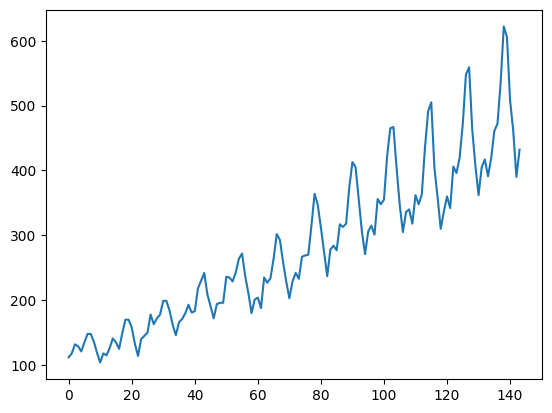

In [ ]:
df_log = plt.plot(df)
plt.show(df_log)

In [ ]:
def check_stationarity(timeseries):

    # Calculate rolling statistics
    rolling_mean = timeseries.rolling(window=12).mean()
    rolling_std = timeseries.rolling(window=12).std()

    # Plot rolling statistics
    plt.figure(figsize=(10, 6))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolling_mean, color='red', label='Rolling Mean')
    plt.plot(rolling_std, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

    # Perform Dickey-Fuller test
    print('Dickey-Fuller Test Results:')
    df_test = adfuller(timeseries)
    df_output = pd.Series(df_test[:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in df_test[4].items():
        df_output[f'Critical Value ({key})'] = value
    print(df_output)

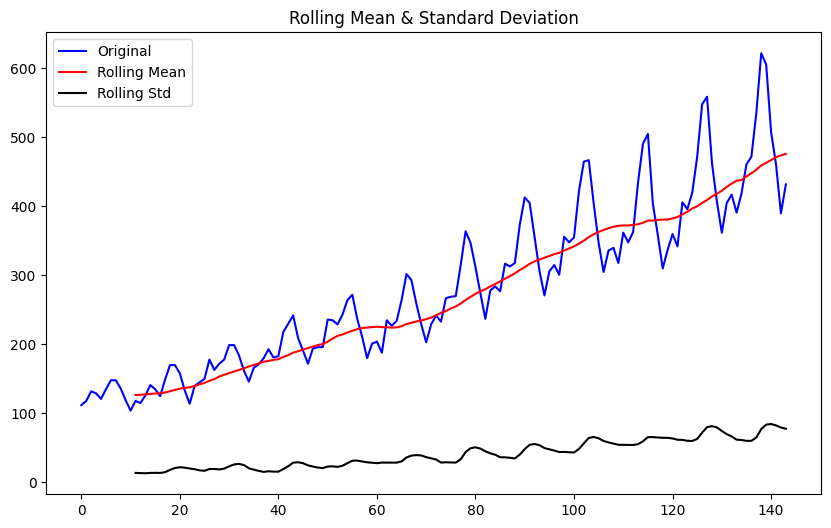

Dickey-Fuller Test Results:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [ ]:
check_stationarity(df)

In [ ]:
df = df.to_frame()
print(df.columns)

Index(['No_passengers_thousands'], dtype='object')


In [ ]:
### Creation of Date column with monthly ending frequency
df['Date'] = pd.date_range(start='1949-01-01', periods=len(df), freq='ME')

In [ ]:
decomposition_result = seasonal_decompose(df["No_passengers_thousands"], model="additive", period=12)

fig = make_subplots(rows=4, cols=1, subplot_titles=("Original Series", "Trend Component", "Seasonal Component", "Residuals"))

fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.observed, mode="lines", name="Original", line=dict(color="darkblue")), row=1, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.trend, mode="lines", name="Trend", line=dict(color="green")), row=2, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.seasonal, mode="lines", name="Seasonality", line=dict(color="purple")), row=3, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.resid, mode="lines", name="Residuals", line=dict(color="orange")), row=4, col=1)

fig.update_layout(title="Decomposition of Time Series", height=900, showlegend=False, plot_bgcolor="whitesmoke")

animation_frames = []
for i in range(len(df)):
    frame = go.Frame(data=[go.Scatter(x=df["Date"][:i+1], y=decomposition_result.observed[:i+1], mode="lines", name="Original", line=dict(color="darkblue")),
                            go.Scatter(x=df["Date"][:i+1], y=decomposition_result.trend[:i+1], mode="lines", name="Trend", line=dict(color="green")),
                            go.Scatter(x=df["Date"][:i+1], y=decomposition_result.seasonal[:i+1], mode="lines", name="Seasonality", line=dict(color="purple")),
                            go.Scatter(x=df["Date"][:i+1], y=decomposition_result.resid[:i+1], mode="lines", name="Residuals", line=dict(color="orange"))],
                      traces=[0, 1, 2, 3])
    animation_frames.append(frame)

fig.frames = animation_frames

fig.update_layout(updatemenus=[dict(type="buttons", showactive=False,
                                    buttons=[dict(label="Play", method="animate", args=[None, {"frame": {"duration": 400, "redraw": True}, "fromcurrent": True, "mode": "immediate"}]),
                                             dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}])])])

fig.show()

In [ ]:
### Reducing the impact of outliers using logarithmic values
df_log = np.log(df["No_passengers_thousands"])
df_log_diff = df_log - df_log.shift()

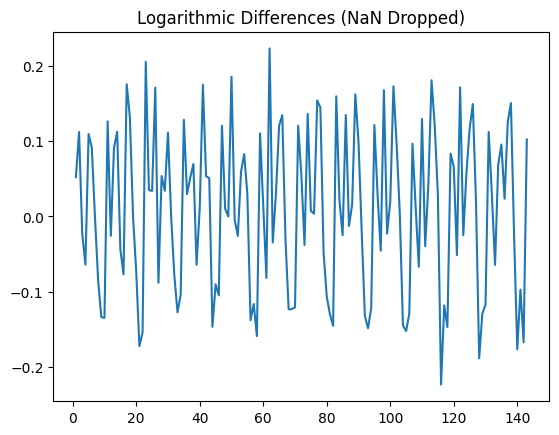

In [ ]:
### Visualization of log differences
plt.plot(df_log_diff.dropna())
plt.title("Logarithmic Differences (NaN Dropped)")
plt.show()

In [ ]:
df_log_diff = df_log_diff.dropna()

### Data Preprocessing

In [ ]:
print(df.columns)

Index(['No_passengers_thousands', 'Date'], dtype='object')


In [ ]:
df = df.drop(columns=['Date'])

In [ ]:
df = np.array(df).reshape(-1,1)### Converting to array
#df

In [ ]:
scaler = MinMaxScaler()
df = scaler.fit_transform(df)

### Train-Test Split

In [ ]:
train = df[0:100,:]
test = df [100:,:]

In [ ]:
def get_data(df, steps):
    dataX = []
    dataY = []
    for i in range(len(df)-steps-1):
        a = df[i:(i+steps), 0]
        dataX.append(a)
        dataY.append(df[i+steps, 0])
    return np.array(dataX), np.array(dataY)

In [ ]:
steps = 2

In [ ]:
X_train, y_train = get_data(train, steps)
X_test, y_test = get_data(test, steps)

In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

#### Define LSTM Model

In [ ]:
LSTMmodel = Sequential()
LSTMmodel.add(Input(shape=(1, steps)))

LSTMmodel.add(LSTM(128, return_sequences=True))
LSTMmodel.add(Dropout(0.2))

LSTMmodel.add(LSTM(64))
LSTMmodel.add(Dropout(0.2))

LSTMmodel.add(Dense(32, activation="relu"))
LSTMmodel.add(Dense(1))

LSTMmodel.compile(loss='mean_squared_error', optimizer='adam')

In [ ]:
LSTMmodel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,593 (463.25 KB)

 Trainable params: 118,593 (463.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

LSTMmodel.fit(X_train, y_train,
          epochs=100,
          batch_size=16,
          validation_split=0.1,
          callbacks=[early_stop, reduce_lr],
          verbose=1)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - loss: 0.0496 - val_loss: 0.1752 - learning_rate: 0.0010
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0339 - val_loss: 0.1274 - learning_rate: 0.0010
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0213 - val_loss: 0.0789 - learning_rate: 0.0010
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0109 - val_loss: 0.0399 - learning_rate: 0.0010
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0103 - val_loss: 0.0270 - learning_rate: 0.0010
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0109 - val_loss: 0.0325 - learning_rate: 0.0010
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0096 - val_loss: 0.0422 - learning_rate: 0.0010
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0080 - val_loss: 0.0420 - learning_rate: 0.0010
Epoch 9/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0081 - val_loss: 0.0339 - learning_rate: 0.0010
Epoch 10/100
6/6 ━━━━━━━━━━

In [ ]:
y_pred = LSTMmodel.predict(X_test)

y_pred = scaler.inverse_transform(y_pred)
y_test = y_test.reshape(-1, 1)
y_test = scaler.inverse_transform(y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 888ms/step


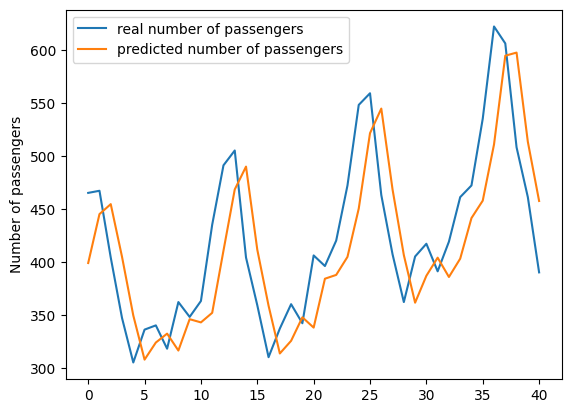

In [ ]:
plt.plot(y_test, label = 'real number of passengers')
plt.plot(y_pred, label = 'predicted number of passengers')
plt.ylabel('Months')
plt.ylabel('Number of passengers')
plt.legend()
plt.show()

In [ ]:
def plot_prediction(y_true, y_pred, sample_size=100):
    sample_size = min(len(y_true), sample_size)

    indices = np.random.choice(range(len(y_true)), size=sample_size, replace=False)
    y_true_sample = y_true[indices]
    y_pred_sample = y_pred[indices]

    plt.figure(figsize=(10, 6))

    plt.plot(y_true_sample, label="Actual Values", marker='o', color='b')

    plt.plot(y_pred_sample, label="Predicted Values", marker='x', color='r')

    plt.title("Comparison of True and Predicted Values")
    plt.xlabel("Samples")
    plt.ylabel("Values")
    plt.legend()
    plt.grid(True)
    plt.show()

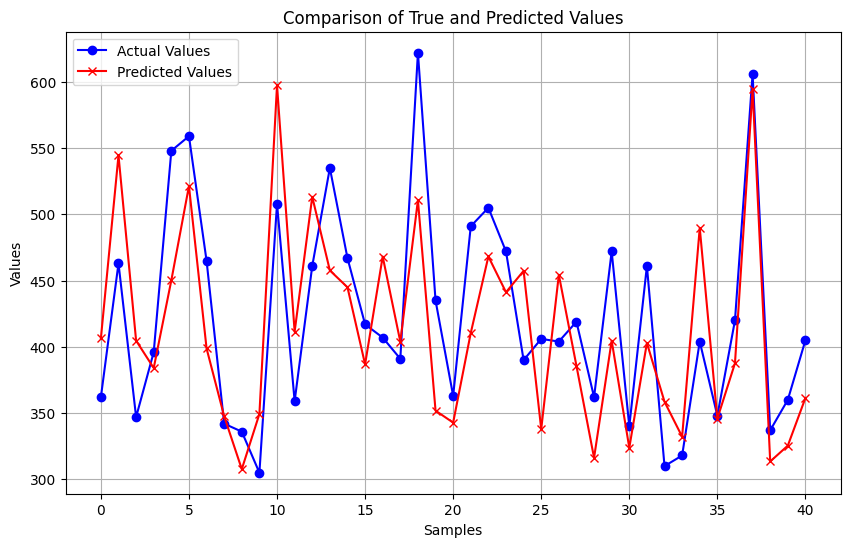

In [ ]:
plot_prediction(y_test, y_pred)